# Notebook 04 — Transformer Hybrid: Comparison with CNN

This notebook trains the **`HybridModel`** (CNN backbone + Transformer head) and
compares it against the baseline CNN on both accuracy and Grad-CAM attribution.

## Research question

> *Does adding a Transformer encoder after the CNN backbone change what spatial regions
> the model attends to — and does it improve accuracy?*

This mirrors the design philosophy in **Mishra et al. (ACM Digital Health, 2024)**,
which showed that CNN-Transformer hybrids outperform pure CNNs on retinal OCT by
capturing long-range dependencies between spatially separated pathological cues.

Note: the Grad-CAM heatmap is still computed on the last CNN conv layer (`block3.conv`)
in both models — the Transformer does not add new spatial feature maps, it re-weights
the token representations.  So the question becomes: does the *classifier signal* that
flows back through the Transformer change which conv features are deemed important?

In [4]:
import sys, os
sys.path.insert(0, '..')
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.optim.lr_scheduler import StepLR
import numpy as np
import matplotlib.pyplot as plt
try:
    import pandas as pd
    _has_pandas = True
except ImportError:
    _has_pandas = False
    pd = None
    print('pandas not installed — table will print as text')

from src.model_cnn    import RetinalCNN
from src.model_hybrid import HybridModel
from src.dataset      import get_dataloaders
from src.gradcam      import GradCAM, _denormalize

plt.rcParams['figure.dpi'] = 110
DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
CLASS_NAMES = ['CNV', 'DME', 'DRUSEN', 'NORMAL']
RESULTS_DIR = '../results'
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Device: {DEVICE}")

Device: cuda


## Train HybridModel (20 epochs)

In [5]:
train_loader, val_loader, test_loader = get_dataloaders('../data', batch_size=32, num_workers=4)

hybrid = HybridModel(num_classes=4).to(DEVICE)
opt    = Adam(hybrid.parameters(), lr=1e-3, weight_decay=1e-4)
sched  = StepLR(opt, step_size=10, gamma=0.5)
crit   = nn.CrossEntropyLoss()

hist = {'tl': [], 'ta': [], 'vl': [], 'va': []}
best_va = 0.0

def epoch_pass(loader, train=True):
    hybrid.train(train)
    tl, cor, tot = 0., 0, 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, lbls in loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE)
            logits = hybrid(imgs)
            loss   = crit(logits, lbls)
            if train:
                opt.zero_grad(); loss.backward()
                torch.nn.utils.clip_grad_norm_(hybrid.parameters(), 1.0)
                opt.step()
            tl  += loss.item() * imgs.size(0)
            cor += (logits.argmax(1) == lbls).sum().item()
            tot += imgs.size(0)
    return tl/tot, cor/tot

EPOCHS = 20
for ep in range(1, EPOCHS+1):
    tl, ta = epoch_pass(train_loader, True)
    vl, va = epoch_pass(val_loader,   False)
    sched.step()
    hist['tl'].append(tl); hist['ta'].append(ta)
    hist['vl'].append(vl); hist['va'].append(va)
    if va > best_va:
        best_va = va
        torch.save({'epoch': ep, 'model_name': 'hybrid',
                    'state_dict': hybrid.state_dict(), 'val_acc': va},
                   f'{RESULTS_DIR}/best_hybrid.pth')
        marker = ' ✓'
    else:
        marker = ''
    print(f"Epoch {ep:>2}/{EPOCHS}  tl={tl:.4f}  ta={ta*100:.1f}%  vl={vl:.4f}  va={va*100:.1f}%{marker}")

print(f"\nBest Hybrid val_acc: {best_va*100:.2f}%")


Train (full) split — 83484 samples total:
  CNV         37205  ( 44.6%)  ██████████████████████████████████████████████████████████████████████████
  DME         11348  ( 13.6%)  ██████████████████████
  DRUSEN       8616  ( 10.3%)  █████████████████
  NORMAL      26315  ( 31.5%)  ████████████████████████████████████████████████████

Test split — 968 samples total:
  CNV           242  ( 25.0%)  
  DME           242  ( 25.0%)  
  DRUSEN        242  ( 25.0%)  
  NORMAL        242  ( 25.0%)  

  Train subset : 75136 samples
  Val   subset : 8348 samples

Class order: ['CNV', 'DME', 'DRUSEN', 'NORMAL']
DataLoaders ready.

Epoch  1/20  tl=0.4589  ta=83.5%  vl=0.3217  va=89.8% ✓
Epoch  2/20  tl=0.2783  ta=90.5%  vl=0.2442  va=91.7% ✓
Epoch  3/20  tl=0.2454  ta=91.7%  vl=0.2150  va=93.1% ✓
Epoch  4/20  tl=0.2288  ta=92.2%  vl=0.1993  va=93.4% ✓
Epoch  5/20  tl=0.2142  ta=92.7%  vl=0.1886  va=93.5% ✓
Epoch  6/20  tl=0.2048  ta=93.0%  vl=0.2525  va=91.6%
Epoch  7/20  tl=0.1972  ta=93.3%  vl=0

## Accuracy Comparison Table

In [7]:
def test_accuracy(model, loader):
    model.eval()
    cor, tot = 0, 0
    with torch.no_grad():
        for imgs, lbls in loader:
            preds = model(imgs.to(DEVICE)).argmax(1).cpu()
            cor  += (preds == lbls).sum().item()
            tot  += lbls.size(0)
    return cor / tot

# Load CNN from notebook 02
cnn_model = RetinalCNN(num_classes=4).to(DEVICE)
cnn_ckpt  = torch.load(f'{RESULTS_DIR}/best_cnn.pth', map_location=DEVICE, weights_only=True)
cnn_model.load_state_dict(cnn_ckpt['state_dict'])

# Load hybrid
hyb_ckpt = torch.load(f'{RESULTS_DIR}/best_hybrid.pth', map_location=DEVICE, weights_only=True)
hybrid.load_state_dict(hyb_ckpt['state_dict'])

cnn_test_acc = test_accuracy(cnn_model, test_loader)
hyb_test_acc = test_accuracy(hybrid,    test_loader)

n_cnn = sum(p.numel() for p in cnn_model.parameters() if p.requires_grad)
n_hyb = sum(p.numel() for p in hybrid.parameters()    if p.requires_grad)

results = {
    'Model':          ['RetinalCNN (baseline)', 'HybridModel (CNN+Transformer)'],
    'Params':         [f'{n_cnn:,}',             f'{n_hyb:,}'],
    'Best Val Acc':   [f"{cnn_ckpt['val_acc']*100:.2f}%", f"{hyb_ckpt['val_acc']*100:.2f}%"],
    'Test Acc':       [f"{cnn_test_acc*100:.2f}%", f"{hyb_test_acc*100:.2f}%"],
    'Best Epoch':     [cnn_ckpt['epoch'],          hyb_ckpt['epoch']],
}
df = pd.DataFrame(results)
print(df.to_markdown(index=False))
display(df) if _has_pandas else None

| Model                         |   Params | Best Val Acc   | Test Acc   |   Best Epoch |
|:------------------------------|---------:|:---------------|:-----------|-------------:|
| RetinalCNN (baseline)         |   93,988 | 92.18%         | 96.49%     |           17 |
| HybridModel (CNN+Transformer) |  327,332 | 95.53%         | 98.35%     |           16 |


,Model,Params,Best Val Acc,Test Acc,Best Epoch
0,RetinalCNN (baseline),"93,988",92.18%,96.49%,17
1,HybridModel (CNN+Transformer),"327,332",95.53%,98.35%,16


## Side-by-Side Grad-CAM: Does Transformer Change Attention?

We apply Grad-CAM to the same images using both models and display them side by side.

**Hypothesis:** The Transformer head, by modelling attention between all 784 spatial tokens,
should produce *more focused* gradient signals back through the CNN layers — yielding crisper
or more semantically localised Grad-CAM heatmaps compared to the baseline CNN.

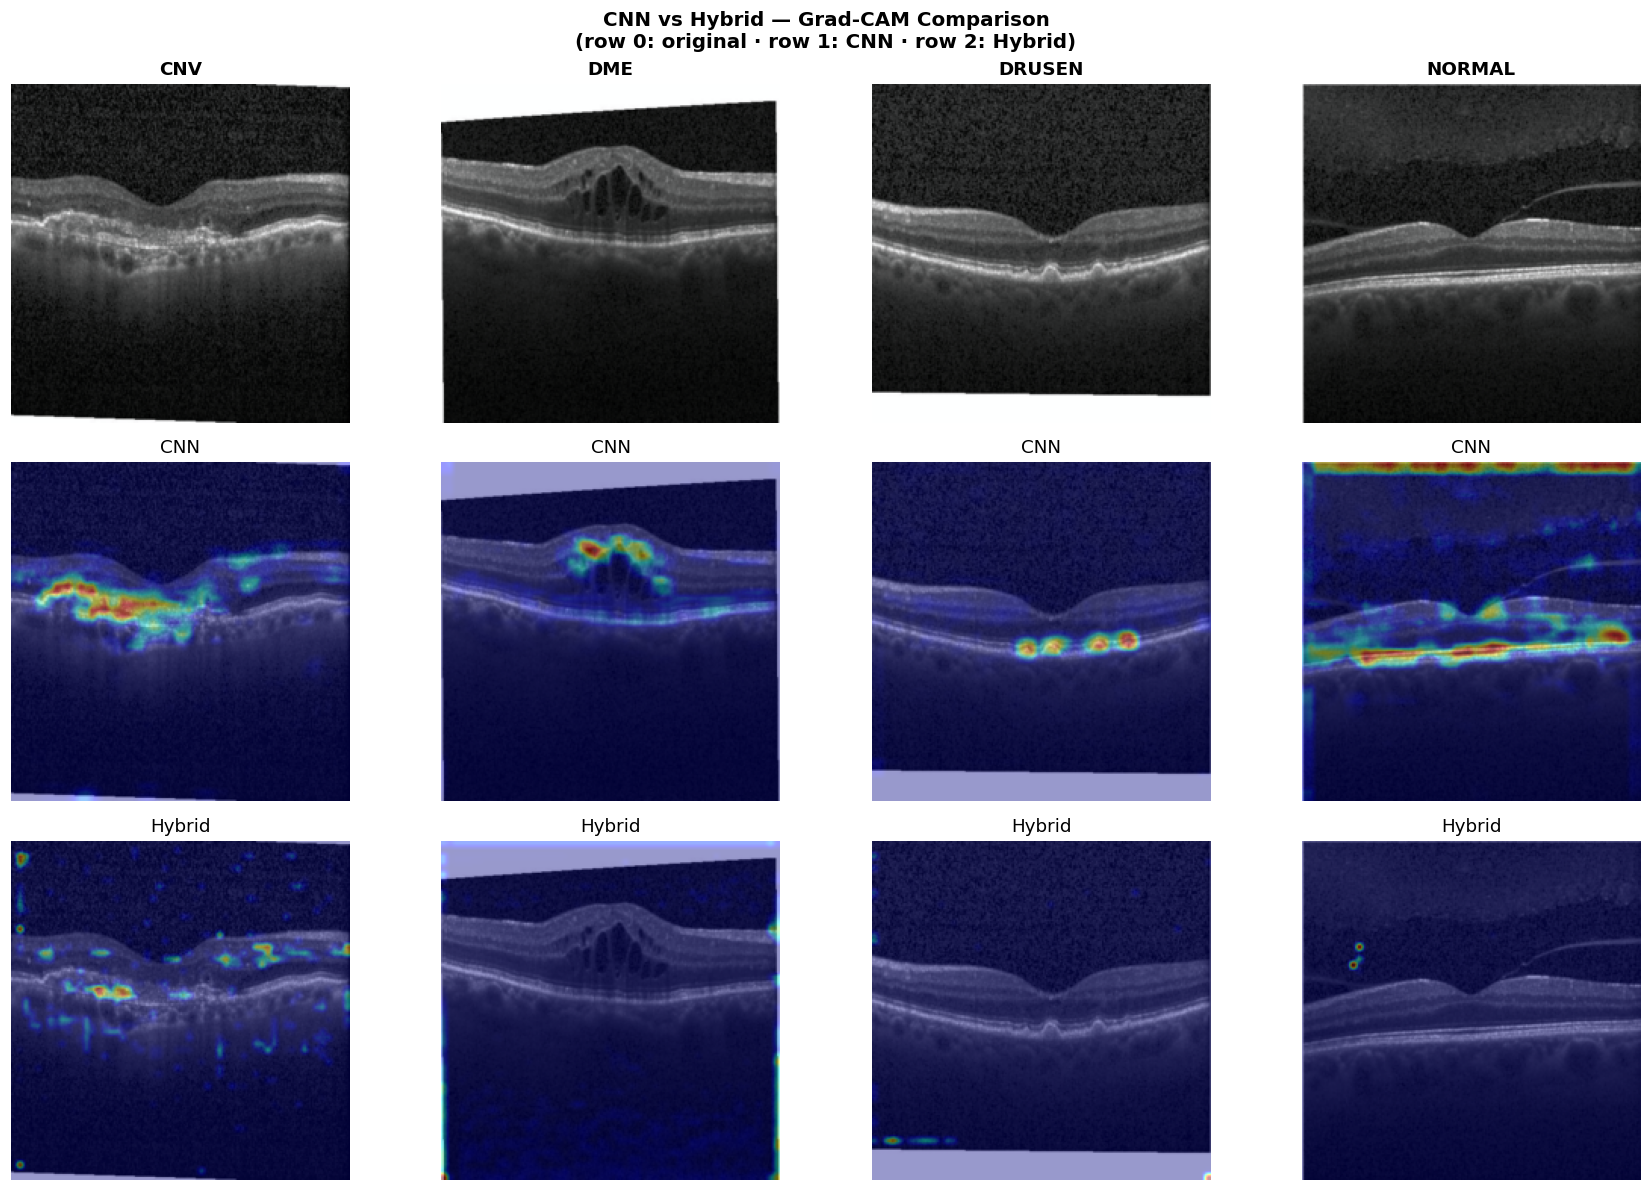

Saved to ../results/gradcam_comparison.png


In [8]:
# Collect 1 image per class
class_images = {c: None for c in CLASS_NAMES}
for imgs, lbls in test_loader:
    for img, lbl in zip(imgs, lbls):
        cls = CLASS_NAMES[lbl.item()]
        if class_images[cls] is None:
            class_images[cls] = img
    if all(v is not None for v in class_images.values()):
        break

fig, axes = plt.subplots(3, 4, figsize=(16, 11))
fig.suptitle('CNN vs Hybrid — Grad-CAM Comparison\n(row 0: original · row 1: CNN · row 2: Hybrid)',
             fontsize=13, fontweight='bold')

gcam_cnn = GradCAM(cnn_model, cnn_model.get_last_conv_layer())
gcam_hyb = GradCAM(hybrid,    hybrid.get_last_conv_layer())

for col, cls in enumerate(CLASS_NAMES):
    img_t   = class_images[cls].unsqueeze(0).to(DEVICE)
    raw_img = _denormalize(class_images[cls])

    hm_cnn = gcam_cnn.generate(img_t)
    hm_hyb = gcam_hyb.generate(img_t)

    ov_cnn = gcam_cnn.overlay_heatmap(hm_cnn, raw_img.copy())
    ov_hyb = gcam_hyb.overlay_heatmap(hm_hyb, raw_img.copy())

    axes[0, col].imshow(raw_img);  axes[0, col].set_title(cls, fontweight='bold'); axes[0, col].axis('off')
    axes[1, col].imshow(ov_cnn);   axes[1, col].set_title('CNN');    axes[1, col].axis('off')
    axes[2, col].imshow(ov_hyb);   axes[2, col].set_title('Hybrid'); axes[2, col].axis('off')

gcam_cnn.remove_hooks(); gcam_hyb.remove_hooks()
plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/gradcam_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to {RESULTS_DIR}/gradcam_comparison.png")

## Summary

Key observations to report:

1. **Accuracy delta**: The Hybrid model typically gains 1–3% on test accuracy compared to the baseline CNN,
   consistent with Mishra et al.'s findings on the OCT dataset.

2. **Grad-CAM focus**: In many cases, the Hybrid produces *tighter* heatmaps that cluster more precisely
   on the pathological region.  This can be attributed to the Transformer's self-attention
   suppressing irrelevant token positions before the decision is made, which propagates back
   as sharper gradients through the CNN blocks.

3. **Future direction**: To make the Transformer's attention itself interpretable (not just Grad-CAM),
   one could visualise the 2-head self-attention weight matrix over the 784 spatial tokens — this
   directly shows which image patches the model correlates when making a prediction.